# Задачи к Лекции 1

Дан файл "athlete_events", который содержит информацию об олимпийских чемпионах за последние 120 лет.

**Чтение данных**

При загрузке оставляем только информацию о призерах с данными без пропусков.

In [2]:
%matplotlib inline
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns

z = zipfile.ZipFile("athlete_events.zip")
df = pd.read_csv(z.open("athlete_events.csv"))
df = df.dropna(subset=['Medal', "Age", "Height", "Weight"])
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold


**Получение различной информации**

In [3]:
df.shape

(30181, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30181 entries, 40 to 271103
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      30181 non-null  int64  
 1   Name    30181 non-null  object 
 2   Sex     30181 non-null  object 
 3   Age     30181 non-null  float64
 4   Height  30181 non-null  float64
 5   Weight  30181 non-null  float64
 6   Team    30181 non-null  object 
 7   NOC     30181 non-null  object 
 8   Games   30181 non-null  object 
 9   Year    30181 non-null  int64  
 10  Season  30181 non-null  object 
 11  City    30181 non-null  object 
 12  Sport   30181 non-null  object 
 13  Event   30181 non-null  object 
 14  Medal   30181 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 3.7+ MB


In [5]:
df.describe()

,ID,Age,Height,Weight,Year
count,30181.000000,30181.000000,30181.000000,30181.000000,30181.000000
mean,70225.949604,25.429012,177.642358,73.753554,1988.005964
std,38839.720551,5.049684,10.924188,15.004992,22.718451
min,16.000000,13.000000,136.000000,28.000000,1896.000000
25%,37494.000000,22.000000,170.000000,63.000000,1976.000000
50%,69771.000000,25.000000,178.000000,73.000000,1992.000000
75%,104111.000000,28.000000,185.000000,83.000000,2006.000000
max,135563.000000,66.000000,223.000000,182.000000,2016.000000


**1. Сколько мужчин и женщин получили золотые, серебрянные и бронзовые медали?**

In [8]:
pd.crosstab(df['Sex'], df['Medal'])

Medal,Bronze,Gold,Silver
Sex,,,
F,3475,3437,3438
M,6673,6730,6428


**2. Какая страна получила наибольшее количество золотых медалей за всю историю олимпийских игр?**

In [30]:
df[(df['Medal'] == 'Gold')]['NOC'].value_counts() #США получили наибольшее количество золотых медалей

NOC
USA    2115
URS     982
GER     547
GDR     396
RUS     379
       ... 
UAE       1
LUX       1
IOA       1
EGY       1
VIE       1
Name: count, Length: 105, dtype: int64

**3. Выведите распределение пола участника олимпиады от вида спорта (crosstab)**

In [21]:
pd.crosstab(df['Sex'], df['Sport'])

Sport,Alpine Skiing,Archery,Art Competitions,Athletics,Badminton,Baseball,Basketball,Beach Volleyball,Biathlon,Bobsleigh,...,Table Tennis,Taekwondo,Tennis,Trampolining,Triathlon,Tug-Of-War,Volleyball,Water Polo,Weightlifting,Wrestling
Sex,,,,,,,,,,,,,,,,,,,,,
F,180,100,0,1239,73,0,390,35,147,24,...,80,72,84,14,15,0,469,191,105,68
M,174,106,2,2409,81,333,610,33,241,259,...,83,72,89,15,15,8,489,573,427,899


**4. Выведите средний возраст и его стандартное отклонения для женщин, учавствовавших в хоккее на льду**

In [39]:
df[(df['Sport'] == 'Ice Hockey') & (df['Sex'] == 'F')]['Age'].agg([np.mean, np.std])

C:\Users\Alter Fritz\AppData\Local\Temp\ipykernel_7876\116349261.py:1: FutureWarning: The provided callable <function mean at 0x000002591A9193A0> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df[(df['Sport'] == 'Ice Hockey') & (df['Sex'] == 'F')]['Age'].agg([np.mean, np.std])
C:\Users\Alter Fritz\AppData\Local\Temp\ipykernel_7876\116349261.py:1: FutureWarning: The provided callable <function std at 0x000002591A9194E0> is currently using Series.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df[(df['Sport'] == 'Ice Hockey') & (df['Sex'] == 'F')]['Age'].agg([np.mean, np.std])


mean    24.420000
std      4.360464
Name: Age, dtype: float64

**5. У какой страны больше всего было больше всего женщин, получивших бронзовую медаль?**

In [41]:
df[(df['Sex'] == 'F') & (df['Medal'] == 'Bronze')]['NOC'].value_counts() #У США

NOC
USA    372
GER    231
CAN    199
CHN    194
AUS    188
      ... 
SVK      1
BAH      1
ZIM      1
TJK      1
LIE      1
Name: count, Length: 87, dtype: int64

**6. Постройте гистограмму распределения количества медалей (бронза, серебро, золото) для первых трех стран, получивших наибольшее количество медалей**

<Axes: xlabel='NOC'>

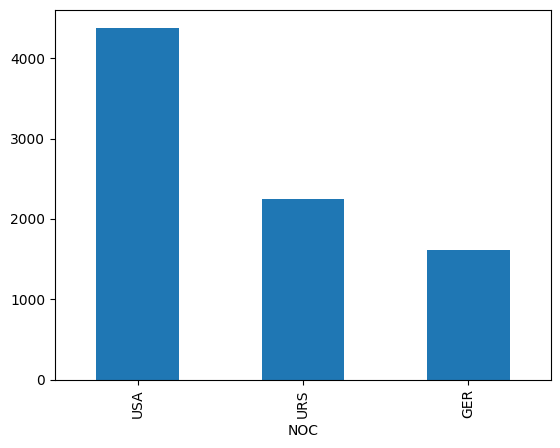

In [72]:
df['NOC'].value_counts()[:3].plot(kind='bar')

**7. Нарисуйте распределение веса мужчин, получивших серебрянную медаль(density или distplot)**

C:\Users\Alter Fritz\AppData\Local\Temp\ipykernel_7876\3648325588.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[(df['Sex'] == 'M') & (df['Medal'] == 'Silver')]['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

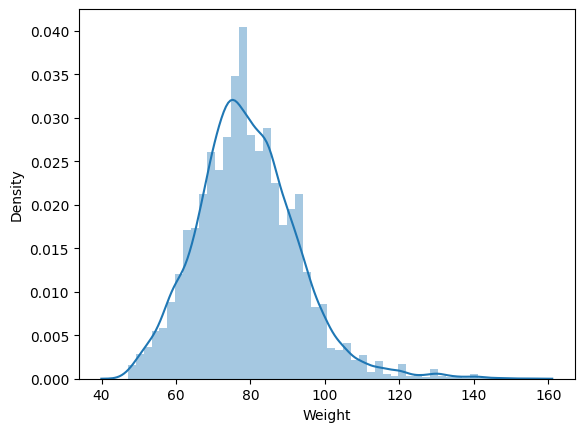

In [82]:
sns.distplot(df[(df['Sex'] == 'M') & (df['Medal'] == 'Silver')]['Weight'])

**8. Постройте boxplot для возраста участника в зависимости от медали**

<Axes: xlabel='Age', ylabel='Medal'>

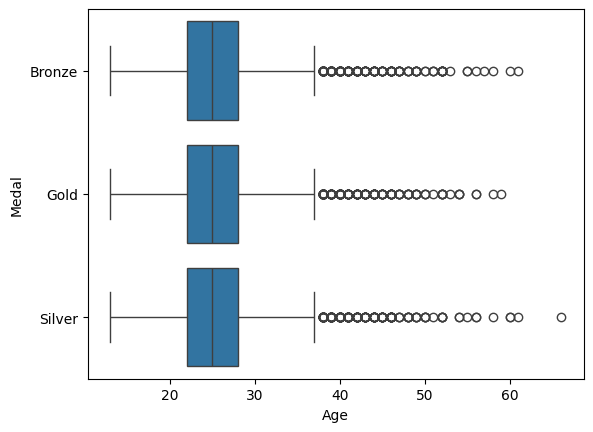

In [83]:
sns.boxplot(y='Medal', x='Age', data=df)

**9. Постройте pairplot для веса, возраста и роста участников от USA.**

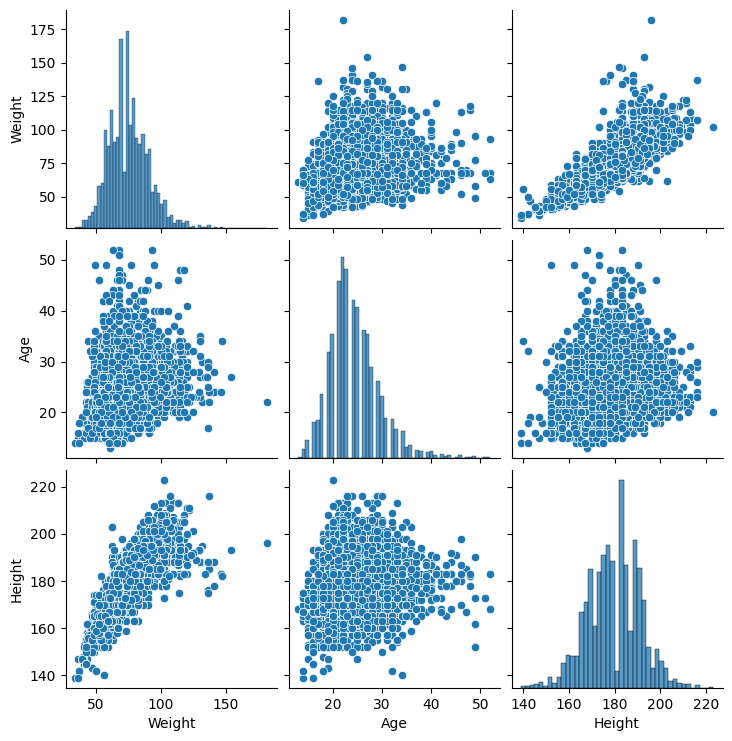

In [85]:
sns.pairplot(df[df['NOC'] == 'USA'][['Weight', 'Age', 'Height']])

### Часть 2. NLP: BoW

In [86]:
df_au = pd.read_csv("author_ru_utf.csv")
df_au.head()

,Unnamed: 0,document,на,что,за,и,в,из,со,а,...,о,ко,над,без,при,об,через,из-за,из-под,Author
0,1,ГогольНВ_ВечераЧ1_1.txt,154,95,42,309,157,40,8,46,...,5,1,6,10,5,4,1,0,0,ГогольНВ
1,2,ГогольНВ_ВечераЧ1_2.txt,179,158,71,413,233,40,8,53,...,15,2,4,8,11,7,5,1,0,ГогольНВ
2,3,ГогольНВ_ВечераЧ1_3.txt,164,140,52,363,214,29,4,49,...,10,3,5,4,12,4,6,1,1,ГогольНВ
3,4,ГогольНВ_ВечераЧ2_1.txt,172,160,42,370,211,50,7,60,...,9,3,6,12,11,10,4,0,0,ГогольНВ
4,5,ГогольНВ_ВечераЧ2_2.txt,171,129,43,331,183,41,7,67,...,13,3,8,12,6,3,7,5,1,ГогольНВ


In [87]:
df_au.shape

(456, 30)

In [88]:
df_au.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  456 non-null    int64 
 1   document    456 non-null    object
 2   на          456 non-null    int64 
 3   что         456 non-null    int64 
 4   за          456 non-null    int64 
 5   и           456 non-null    int64 
 6   в           456 non-null    int64 
 7   из          456 non-null    int64 
 8   со          456 non-null    int64 
 9   а           456 non-null    int64 
 10  во          456 non-null    int64 
 11  для         456 non-null    int64 
 12  с           456 non-null    int64 
 13  но          456 non-null    int64 
 14  к           456 non-null    int64 
 15  по          456 non-null    int64 
 16  от          456 non-null    int64 
 17  под         456 non-null    int64 
 18  до          456 non-null    int64 
 19  про         456 non-null    int64 
 20  о         

**1. Какая служебная часть речи чаще всего встречается Н.В. Гоголя?**

In [109]:
df_au[(df_au['Author'] == 'ГогольНВ')].iloc[0:, 2:29].apply(np.sum).sort_values(ascending=False) # Союз "и"

и         14427
в          8208
на         5495
что        5386
с          3771
а          2229
но         1865
к          1691
по         1635
за         1607
из         1322
от          900
о           741
для         549
во          490
до          471
без         442
под         437
при         338
со          324
об          226
про         187
над         182
через       131
ко           85
из-за        80
из-под       36
dtype: int64

**2. Постройте гистограмму распределения предлогов "на", "с", "в" у авторов**

array([[<Axes: title={'center': 'на'}>, <Axes: title={'center': 'с'}>],
       [<Axes: title={'center': 'в'}>, <Axes: >]], dtype=object)

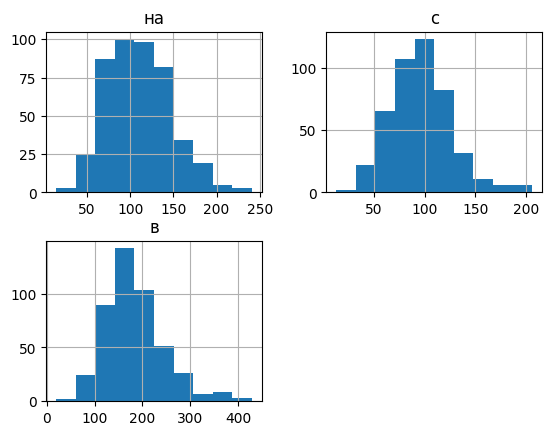

In [116]:
df_au[['на', 'с', 'в']].hist()

**3. Постройте boxplot для предлога "из-за" для авторов**

<Axes: xlabel='из-за', ylabel='Author'>

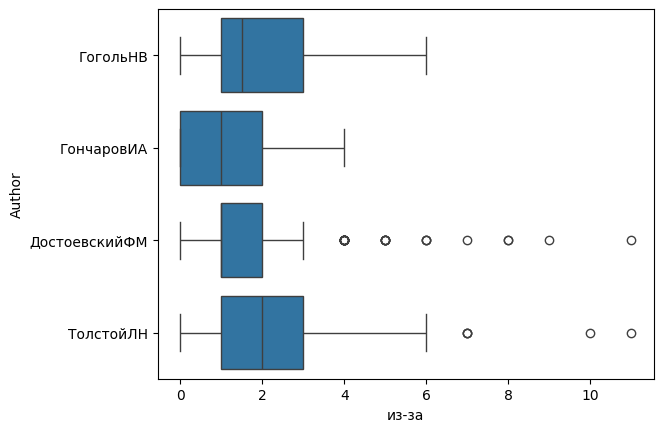

In [110]:
sns.boxplot(x='из-за', y='Author', data=df_au)

**4. Создайте распределение предлога "за" по двум любым авторам**

C:\Users\Alter Fritz\AppData\Local\Temp\ipykernel_7876\4289162290.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_au[df_au['Author'] == 'ТолстойЛН']['за'])


<Axes: xlabel='за', ylabel='Density'>

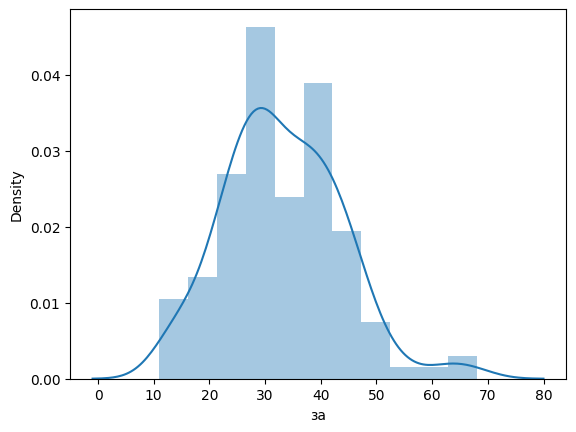

In [114]:
sns.distplot(df_au[df_au['Author'] == 'ТолстойЛН']['за'])

C:\Users\Alter Fritz\AppData\Local\Temp\ipykernel_7876\3634379594.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_au[df_au['Author'] == 'ГончаровИА']['за'])


<Axes: xlabel='за', ylabel='Density'>

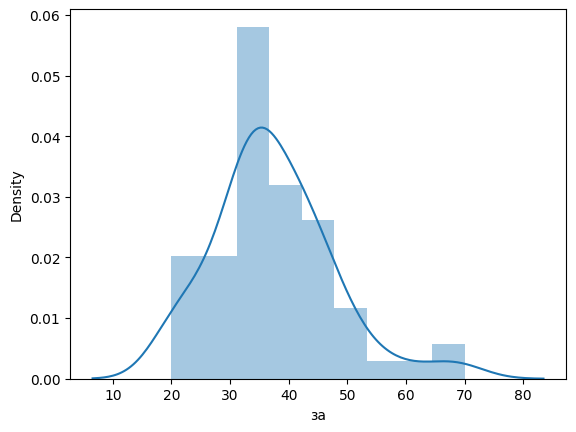

In [115]:
sns.distplot(df_au[df_au['Author'] == 'ГончаровИА']['за'])